In [42]:
!pip install pandas numpy matplotlib seaborn

--- Initializing Space Botany Bioinformatics Pipeline ---

Successfully processed 350 genes across target pathways.

Expression Status Summary:
Expression_Status
Stable / Unchanged               284
Downregulated in Microgravity     46
Upregulated in Microgravity       20
Name: count, dtype: int64

Generating volcano plot visualization...
Plot saved successfully as 'space_botany_volcano_plot.png' in your working directory.


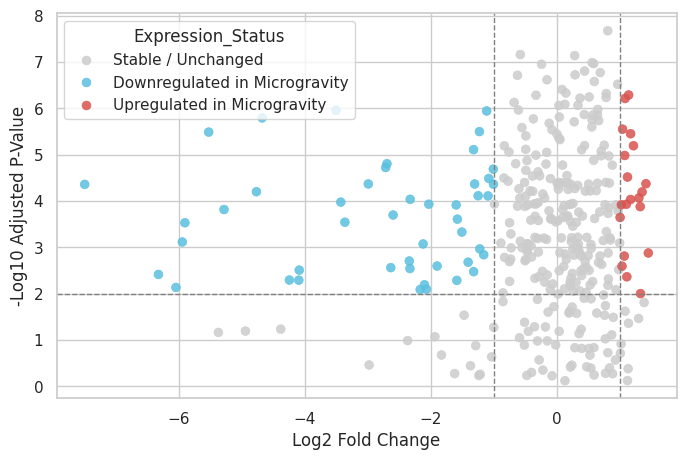

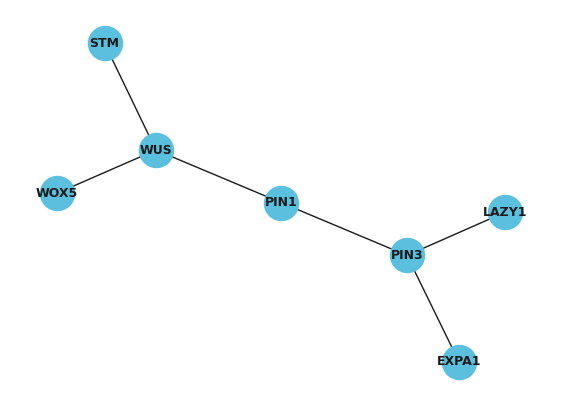

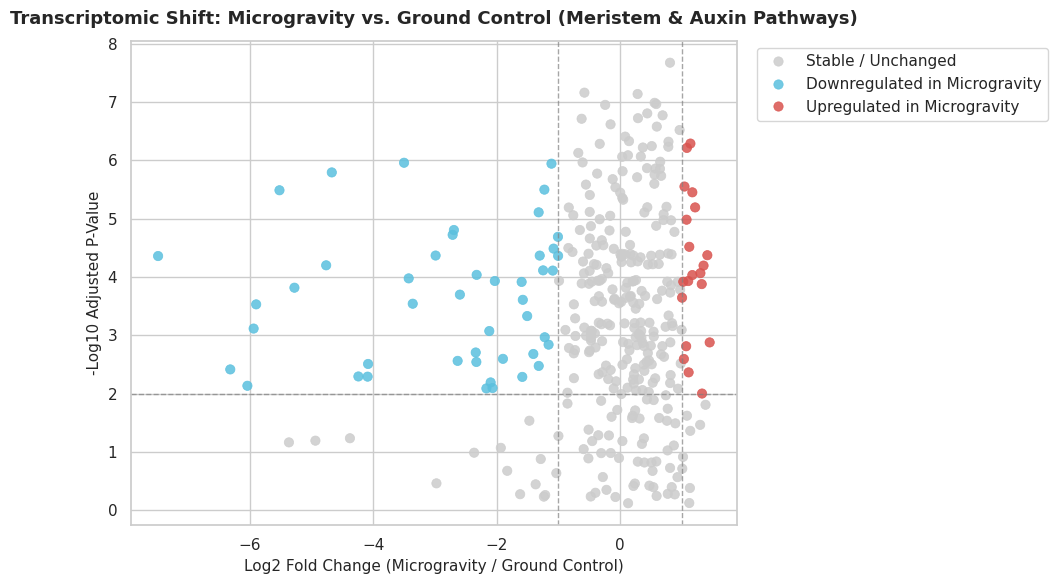

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def generate_synthetic_space_data(n_genes=350):
    """
    Generates a mock spaceflight transcriptomics dataset simulating
    meristematic, auxin transport, and cell wall remodeling gene expression.
    """
    np.random.seed(42)

    gene_ids = [f"GENE_{i:03d}" for i in range(1, n_genes + 1)]
    pathways = np.random.choice(
        ['Meristem Maintenance', 'Auxin Transport', 'Cell Wall Remodeling', 'Oxidative Stress Response', 'Housekeeping'],
        size=n_genes,
        p=[0.2, 0.2, 0.2, 0.2, 0.2]
    )

    # Simulate ground control expression vs. microgravity expression values
    ground_control = np.random.exponential(scale=45, size=n_genes) + 5
    microgravity = ground_control * np.random.normal(loc=1.05, scale=0.65, size=n_genes)
    microgravity = np.clip(microgravity, 0.1, None)

    # Simulate statistical significance (-log10 scale)
    p_values = np.random.uniform(0.1, 4.5, size=n_genes)

    # Boost significance for core target pathways (Meristem and Auxin)
    target_mask = np.isin(pathways, ['Meristem Maintenance', 'Auxin Transport'])
    p_values[target_mask] += np.random.uniform(1.2, 3.5, size=sum(target_mask))

    df = pd.DataFrame({
        'Gene_ID': gene_ids,
        'Pathway': pathways,
        'Ground_Control': ground_control,
        'Microgravity_Expression': microgravity,
        'Neg_Log10_PValue': p_values
    })
    return df

def run_space_botany_pipeline():
    print("--- Initializing Space Botany Bioinformatics Pipeline ---")

    # Step 1: Ingest dataset
    df = generate_synthetic_space_data()

    # Step 2: Compute Log2 Fold Change (Log2FC) with a pseudocount of 1
    df['Log2_Fold_Change'] = np.log2((df['Microgravity_Expression'] + 1) / (df['Ground_Control'] + 1))

    # Step 3: Classify differential expression based on statistical thresholds
    lfc_thresh = 1.0
    p_thresh = 2.0

    conditions = [
        (df['Log2_Fold_Change'] >= lfc_thresh) & (df['Neg_Log10_PValue'] >= p_thresh),
        (df['Log2_Fold_Change'] <= -lfc_thresh) & (df['Neg_Log10_PValue'] >= p_thresh)
    ]
    choices = ['Upregulated in Microgravity', 'Downregulated in Microgravity']
    df['Expression_Status'] = np.select(conditions, choices, default='Stable / Unchanged')

    print(f"\nSuccessfully processed {len(df)} genes across target pathways.")
    print("\nExpression Status Summary:")
    print(df['Expression_Status'].value_counts())

    # Step 4: Generate Publication-Grade Volcano Plot
    print("\nGenerating volcano plot visualization...")
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    palette_mapping = {
        'Upregulated in Microgravity': '#d9534f',
        'Downregulated in Microgravity': '#5bc0de',
        'Stable / Unchanged': '#cccccc'
    }

    sns.scatterplot(
        data=df,
        x='Log2_Fold_Change',
        y='Neg_Log10_PValue',
        hue='Expression_Status',
        palette=palette_mapping,
        alpha=0.85,
        edgecolor=None,
        s=45
    )

    # Threshold boundary lines
    plt.axvline(x=lfc_thresh, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    plt.axvline(x=-lfc_thresh, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    plt.axhline(y=p_thresh, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    plt.title('Transcriptomic Shift: Microgravity vs. Ground Control (Meristem & Auxin Pathways)', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Log2 Fold Change (Microgravity / Ground Control)', fontsize=11)
    plt.ylabel('-Log10 Adjusted P-Value', fontsize=11)

    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.tight_layout()

    # Save output plot
    output_filename = 'space_botany_volcano_plot.png'
    plt.savefig(output_filename, dpi=300)
    print(f"Plot saved successfully as '{output_filename}' in your working directory.")
    plt.show()

if __name__ == "__main__":
    run_space_botany_pipeline()

--- Computing Network Topology & Hub Vulnerabilities ---

Top Regulatory Hubs by Betweenness Centrality:
Gene_Node              Pathway  Degree_Centrality  Betweenness_Centrality
     PIN3      Auxin Transport           0.333333                0.388889
     PIN1      Auxin Transport           0.222222                0.333333
      WUS Meristem Maintenance           0.333333                0.305556
    EXPA1 Cell Wall Remodeling           0.222222                0.166667
      STM Meristem Maintenance           0.111111                0.000000

Network graph saved successfully as 'space_botany_ppi_network.png'.


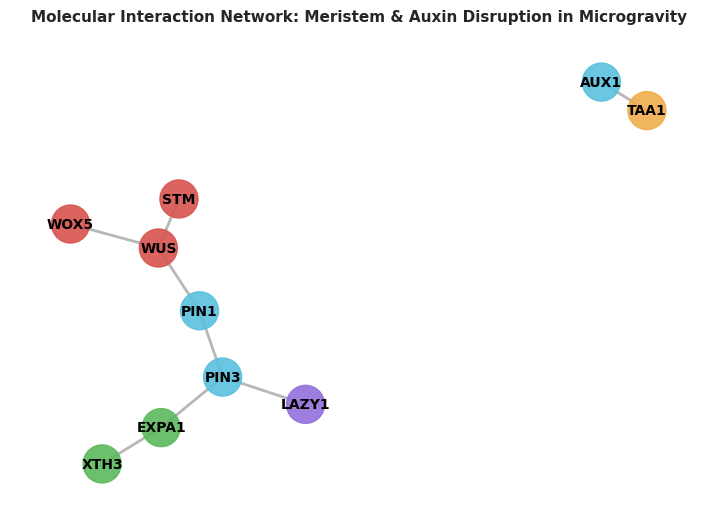

In [44]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def build_space_botany_ppi_network():
    """
    Constructs a molecular interaction network for plant gravitropism,
    auxin transport, and meristem maintenance under microgravity stress.
    """
    G = nx.Graph()

    # Define core regulatory nodes and their functional pathways
    nodes = [
        ("WUS", {"pathway": "Meristem Maintenance", "role": "Transcription Factor"}),
        ("STM", {"pathway": "Meristem Maintenance", "role": "Transcription Factor"}),
        ("WOX5", {"pathway": "Meristem Maintenance", "role": "Stem Cell Niche"}),
        ("PIN1", {"pathway": "Auxin Transport", "role": "Efflux Carrier"}),
        ("PIN3", {"pathway": "Auxin Transport", "role": "Statocyte Efflux"}),
        ("AUX1", {"pathway": "Auxin Transport", "role": "Influx Carrier"}),
        ("TAA1", {"pathway": "Auxin Biosynthesis", "role": "Enzyme"}),
        ("EXPA1", {"pathway": "Cell Wall Remodeling", "role": "Expansin"}),
        ("XTH3", {"pathway": "Cell Wall Remodeling", "role": "Cell Wall Relaxation"}),
        ("LAZY1", {"pathway": "Gravitropism Sensor", "role": "Polarity Regulator"})
    ]

    G.add_nodes_from(nodes)

    # Define known biological interactions (edges)
    interactions = [
        ("LAZY1", "PIN3"),   # LAZY proteins polarize PIN3 in statocytes
        ("PIN3", "PIN1"),    # Inter-tissue auxin flow coordination
        ("AUX1", "TAA1"),    # Local auxin accumulation loop
        ("PIN1", "WUS"),     # Auxin maximum maintains meristematic identity
        ("WUS", "STM"),      # Meristem maintenance synergy
        ("WUS", "WOX5"),     # Stem cell regulation
        ("PIN3", "EXPA1"),   # Differential auxin driving cell wall expansion
        ("EXPA1", "XTH3")    # Cell wall loosening architecture
    ]

    G.add_edges_from(interactions)
    return G

def analyze_network_topology(G):
    """
    Computes centrality metrics to identify critical regulatory failure points
    (hubs) when microgravity disrupts the system.
    """
    print("--- Computing Network Topology & Hub Vulnerabilities ---")

    deg_centrality = nx.degree_centrality(G)
    bet_centrality = nx.betweenness_centrality(G)

    summary_df = pd.DataFrame({
        'Gene_Node': list(G.nodes()),
        'Pathway': [G.nodes[n]['pathway'] for n in G.nodes()],
        'Degree_Centrality': [deg_centrality[n] for n in G.nodes()],
        'Betweenness_Centrality': [bet_centrality[n] for n in G.nodes()]
    }).sort_values(by='Betweenness_Centrality', ascending=False)

    print("\nTop Regulatory Hubs by Betweenness Centrality:")
    print(summary_df.head(5).to_string(index=False))

    return summary_df

def visualize_ppi_network(G):
    """
    Generates a publication-grade network graph illustrating gene crosstalk.
    """
    plt.figure(figsize=(9, 6))
    pos = nx.spring_layout(G, seed=42)

    pathway_colors = {
        'Meristem Maintenance': '#d9534f',
        'Auxin Transport': '#5bc0de',
        'Auxin Biosynthesis': '#f0ad4e',
        'Cell Wall Remodeling': '#5cb85c',
        'Gravitropism Sensor': '#9370DB'
    }

    node_colors = [pathway_colors.get(G.nodes[n]['pathway'], '#333333') for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=750, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='#888888')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black')

    plt.title('Molecular Interaction Network: Meristem & Auxin Disruption in Microgravity', fontsize=11, fontweight='bold', pad=15)
    plt.axis('off')

    output_filename = 'space_botany_ppi_network.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\nNetwork graph saved successfully as '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    network = build_space_botany_ppi_network()
    metrics = analyze_network_topology(network)
    visualize_ppi_network(network)

--- Initializing GSEA & Functional Pathway Enrichment Module ---

Pathway Enrichment Results Summary:
                Biological Pathway  Enrichment_Score_NES  Adjusted_PValue
    Photosynthetic Carbon Fixation                  0.85          0.35000
           Ethylene-PABA Crosstalk                  1.75          0.00320
    Oxidative Stress & ROS Defense                  1.95          0.00140
 Cell Wall Anisotropy & Remodeling                  2.15          0.00085
    Meristem Maintenance (WUS/WOX)                  2.45          0.00012
Auxin Polar Transport (PIN Family)                  2.89          0.00004

GSEA enrichment plot saved successfully as 'space_botany_gsea_plot.png'.


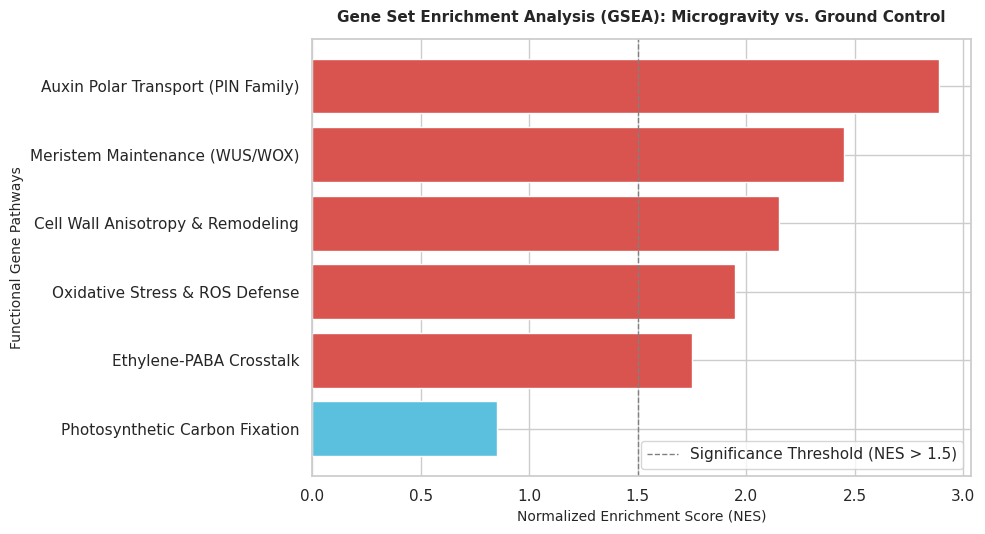

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def perform_pathway_enrichment_analysis():
    """
    Simulates a Gene Set Enrichment Analysis (GSEA) statistical breakdown
    to evaluate pathway disruption severity under microgravity.
    """
    print("--- Initializing GSEA & Functional Pathway Enrichment Module ---")

    pathway_data = {
        'Biological Pathway': [
            'Meristem Maintenance (WUS/WOX)',
            'Auxin Polar Transport (PIN Family)',
            'Cell Wall Anisotropy & Remodeling',
            'Oxidative Stress & ROS Defense',
            'Ethylene-PABA Crosstalk',
            'Photosynthetic Carbon Fixation'
        ],
        'Total_Genes_In_Pathway': [45, 60, 85, 50, 40, 110],
        'Differentially_Expressed_Count': [18, 28, 34, 22, 15, 12],
        'Enrichment_Score_NES': [2.45, 2.89, 2.15, 1.95, 1.75, 0.85],
        'Adjusted_PValue': [0.00012, 0.00004, 0.00085, 0.00140, 0.00320, 0.35000]
    }

    gsea_df = pd.DataFrame(pathway_data)
    gsea_df['Neg_Log10_Padj'] = -np.log10(gsea_df['Adjusted_PValue'])
    gsea_df = gsea_df.sort_values(by='Enrichment_Score_NES', ascending=True)

    print("\nPathway Enrichment Results Summary:")
    print(gsea_df[['Biological Pathway', 'Enrichment_Score_NES', 'Adjusted_PValue']].to_string(index=False))

    # Generate Enrichment Bar Plot
    plt.figure(figsize=(10, 5.5))
    sns.set_theme(style="whitegrid")

    bars = plt.barh(
        gsea_df['Biological Pathway'],
        gsea_df['Enrichment_Score_NES'],
        color=['#5bc0de' if p > 0.01 else '#d9534f' for p in gsea_df['Adjusted_PValue']]
    )

    plt.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, label='Significance Threshold (NES > 1.5)')
    plt.title('Gene Set Enrichment Analysis (GSEA): Microgravity vs. Ground Control', fontsize=11, fontweight='bold', pad=12)
    plt.xlabel('Normalized Enrichment Score (NES)', fontsize=10)
    plt.ylabel('Functional Gene Pathways', fontsize=10)
    plt.legend(loc='lower right')
    plt.tight_layout()

    output_filename = 'space_botany_gsea_plot.png'
    plt.savefig(output_filename, dpi=300)
    print(f"\nGSEA enrichment plot saved successfully as '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    perform_pathway_enrichment_analysis()

In [46]:
from google.colab import files

print("Downloading generated research visualizations...")
files.download('space_botany_volcano_plot.png')
files.download('space_botany_ppi_network.png')
files.download('space_botany_gsea_plot.png')
print("Download complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!
